# BFSI Fraud / Risk Analytics using Support Vector Machine (SVM)

## Problem Statement
A digital payment system processes high-volume transactions where a small fraction may represent fraud due to abnormal spending behavior, location mismatch, or unusual transaction patterns.

## Business Objectives
- Detect fraudulent transactions early
- Reduce false positives in fraud detection
- Improve customer transaction safety
- Identify behavioral risk patterns

## Data Inputs
Transaction amount, transaction time, device, location, account behavior, frequency patterns, and authentication signals.

## ML Objective
Use **Support Vector Machine (SVM)** to classify transactions as **fraudulent** or **legitimate** and evaluate kernel-based separation of complex behavioral patterns.

## 1. Import Required Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

## 2. Load the BFSI Fraud Dataset

The target column is assumed to be:

- `is_fraud = 0` → Legitimate transaction
- `is_fraud = 1` → Fraud transaction

In [4]:
df = pd.read_csv('Datasets/bfsi_fraud_dataset.csv')

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (10000, 9)


,transaction_amount,transaction_hour,transaction_type,device_type,location,failed_login_attempts,transactions_last_24h,account_age_days,is_fraud
0,2346.340450,22,NetBanking,iPhone,Mumbai,9,33,2249,1
1,15050.607155,3,Card,iPhone,Bangalore,0,4,583,0
2,6583.728468,17,Wallet,iPhone,Chennai,8,49,24,1
3,4564.712769,4,UPI,iPhone,Chennai,2,39,873,0
4,848.124352,15,UPI,iPhone,Mumbai,1,25,2550,0


## 3. Basic Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_amount     10000 non-null  float64
 1   transaction_hour       10000 non-null  int64  
 2   transaction_type       10000 non-null  object 
 3   device_type            10000 non-null  object 
 4   location               10000 non-null  object 
 5   failed_login_attempts  10000 non-null  int64  
 6   transactions_last_24h  10000 non-null  int64  
 7   account_age_days       10000 non-null  int64  
 8   is_fraud               10000 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 703.2+ KB


In [4]:
df.describe(include='all')

,transaction_amount,transaction_hour,transaction_type,device_type,location,failed_login_attempts,transactions_last_24h,account_age_days,is_fraud
count,10000.000000,10000.000000,10000,10000,10000,10000.000000,10000.000000,10000.000000,10000.00000
unique,NaN,NaN,4,3,5,NaN,NaN,NaN,NaN
top,NaN,NaN,NetBanking,Android,Chennai,NaN,NaN,NaN,NaN
freq,NaN,NaN,2571,3384,2085,NaN,NaN,NaN,NaN
mean,4887.494773,11.593300,NaN,NaN,NaN,4.504300,25.065500,1805.160200,0.16350
std,4872.023534,6.922708,NaN,NaN,NaN,2.856781,14.070444,1054.408527,0.36984
min,0.058174,0.000000,NaN,NaN,NaN,0.000000,1.000000,1.000000,0.00000
25%,1413.995864,6.000000,NaN,NaN,NaN,2.000000,13.000000,895.000000,0.00000
50%,3391.574793,12.000000,NaN,NaN,NaN,5.000000,25.000000,1812.500000,0.00000
75%,6735.491484,18.000000,NaN,NaN,NaN,7.000000,37.000000,2710.000000,0.00000


In [6]:
print('Missing values:')
print(df.isnull().sum())

print('Target distribution:')
print(df['is_fraud'].value_counts())
print('Target percentage:')
print(df['is_fraud'].value_counts(normalize=True) * 100)

Missing values:
transaction_amount       0
transaction_hour         0
transaction_type         0
device_type              0
location                 0
failed_login_attempts    0
transactions_last_24h    0
account_age_days         0
is_fraud                 0
dtype: int64
Target distribution:
is_fraud
0    8365
1    1635
Name: count, dtype: int64
Target percentage:
is_fraud
0    83.65
1    16.35
Name: proportion, dtype: float64


## 4. Fraud vs Legitimate Transaction Distribution

This helps us understand whether the dataset is balanced or imbalanced.
Fraud datasets are usually imbalanced because fraud cases are fewer than legitimate cases.

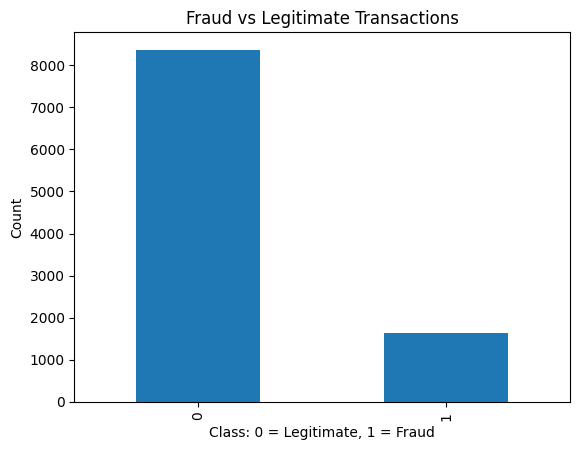

In [7]:
df['is_fraud'].value_counts().plot(kind='bar')
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Class: 0 = Legitimate, 1 = Fraud')
plt.ylabel('Count')
plt.show()

## 5. Feature and Target Separation

We separate input features `X` and output target `y`.

In [12]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['transaction_amount', 'transaction_hour', 'failed_login_attempts', 'transactions_last_24h', 'account_age_days']
Categorical features: ['transaction_type', 'device_type', 'location']


## 7. Train-Test Split

We split the data into training and testing sets.
`stratify=y` preserves the fraud/legitimate ratio in both train and test data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training records:', X_train.shape[0])
print('Testing records:', X_test.shape[0])

Training records: 8000
Testing records: 2000


## 8. Create Preprocessing Pipeline

- Numeric columns → StandardScaler
- Categorical columns → OneHotEncoder

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
encoder = OneHotEncoder(handle_unknown='ignore')
encoded = encoder.fit_transform(df[categorical_features])
print(encoded)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30000 stored elements and shape (10000, 12)>
  Coords	Values
  (0, 1)	1.0
  (0, 6)	1.0
  (0, 11)	1.0
  (1, 0)	1.0
  (1, 6)	1.0
  (1, 7)	1.0
  (2, 3)	1.0
  (2, 6)	1.0
  (2, 8)	1.0
  (3, 2)	1.0
  (3, 6)	1.0
  (3, 8)	1.0
  (4, 2)	1.0
  (4, 6)	1.0
  (4, 11)	1.0
  (5, 3)	1.0
  (5, 4)	1.0
  (5, 9)	1.0
  (6, 2)	1.0
  (6, 5)	1.0
  (6, 11)	1.0
  (7, 1)	1.0
  (7, 5)	1.0
  (7, 9)	1.0
  (8, 3)	1.0
  :	:
  (9991, 11)	1.0
  (9992, 0)	1.0
  (9992, 5)	1.0
  (9992, 9)	1.0
  (9993, 3)	1.0
  (9993, 5)	1.0
  (9993, 11)	1.0
  (9994, 0)	1.0
  (9994, 4)	1.0
  (9994, 10)	1.0
  (9995, 3)	1.0
  (9995, 4)	1.0
  (9995, 10)	1.0
  (9996, 3)	1.0
  (9996, 6)	1.0
  (9996, 10)	1.0
  (9997, 0)	1.0
  (9997, 4)	1.0
  (9997, 8)	1.0
  (9998, 2)	1.0
  (9998, 5)	1.0
  (9998, 11)	1.0
  (9999, 2)	1.0
  (9999, 5)	1.0
  (9999, 11)	1.0


## 9. Train SVM with RBF Kernel

RBF kernel is useful when fraud and legitimate transactions are not separated by a straight line.

In [20]:
svm_rbf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
])

svm_rbf_model.fit(X_train, y_train)

y_pred = svm_rbf_model.predict(X_test)
y_prob = svm_rbf_model.predict_proba(X_test)[:, 1]

## 10. Model Evaluation

Important metrics for fraud detection:

- **Precision**: Out of predicted fraud cases, how many were actually fraud?
- **Recall**: Out of actual fraud cases, how many did the model catch?
- **F1-score**: Balance between precision and recall.
- **False Positive**: Genuine transaction incorrectly marked as fraud.
- **False Negative**: Fraud transaction missed by the model.

In [21]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.968
Precision: 0.8433420365535248
Recall: 0.9877675840978594
F1 Score: 0.9098591549295775
ROC-AUC: 0.9976694067132055
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1673
           1       0.84      0.99      0.91       327

    accuracy                           0.97      2000
   macro avg       0.92      0.98      0.95      2000
weighted avg       0.97      0.97      0.97      2000



## 11. Confusion Matrix

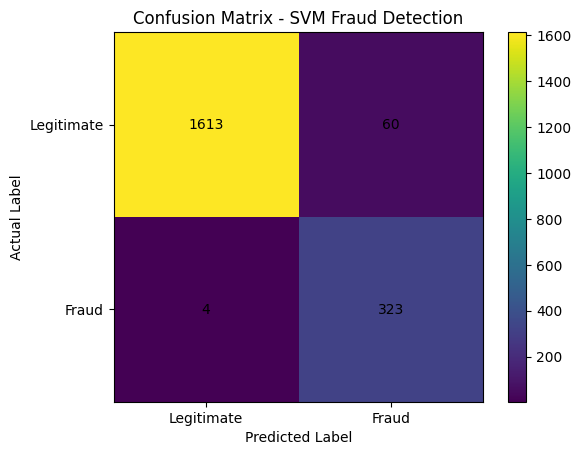

Confusion Matrix:
[[1613   60]
 [   4  323]]


In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title('Confusion Matrix - SVM Fraud Detection')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.yticks([0, 1], ['Legitimate', 'Fraud'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

print('Confusion Matrix:')
print(cm)

## 12. ROC Curve

ROC curve shows the trade-off between detecting fraud and false alarms.
A higher AUC means better class separation.
1. True Positive Rate (TPR)

Same as Recall.

TPR=
TP+FN/
TP


Meaning:

Out of all actual frauds, how many did we catch?

2. False Positive Rate (FPR)
FPR=
FP+TN/
FP



Meaning:

Out of all legitimate transactions, how many were wrongly flagged as fraud?
	




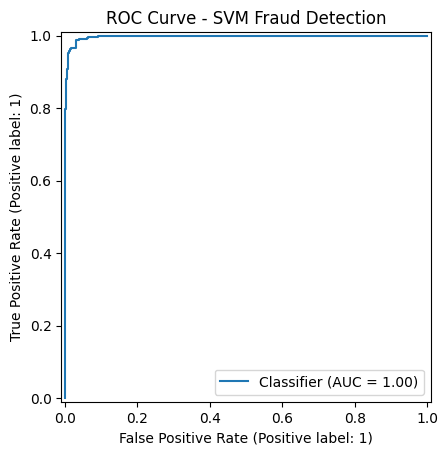

0.9976694067132055


In [24]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Curve - SVM Fraud Detection')
plt.show()
auc = roc_auc_score(y_test, y_prob)

# ROC uses two values i.e True Positive Rate (TPR) , False Positive Rate (FPR)


print(auc)


## 13. Compare Different SVM Kernels

We compare:

- Linear kernel
- Polynomial kernel
- RBF kernel

This helps evaluate kernel-based separation of complex fraud behavior.

In [17]:
kernels = ['linear', 'poly', 'rbf']
results = []

for kernel in kernels:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel=kernel, class_weight='balanced', probability=True, random_state=42))
    ])
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Kernel': kernel,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    })

kernel_results = pd.DataFrame(results)
kernel_results

,Kernel,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,linear,0.9105,0.657447,0.944954,0.775408,0.979032
1,poly,0.9725,0.873626,0.972477,0.920405,0.995975
2,rbf,0.9680,0.843342,0.987768,0.909859,0.997669


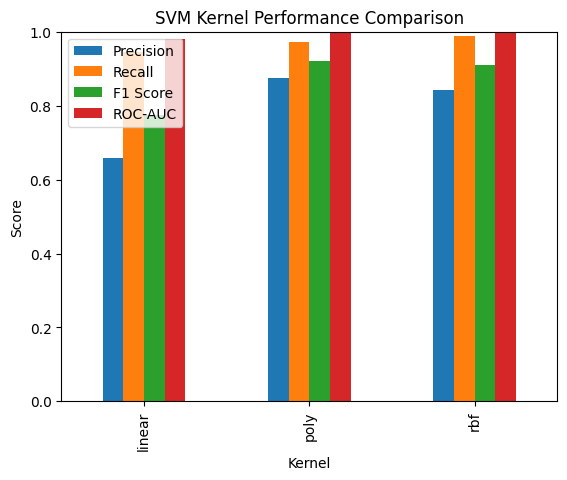

In [19]:
kernel_results.set_index('Kernel')[['Precision', 'Recall', 'F1 Score', 'ROC-AUC']].plot(kind='bar')
plt.title('SVM Kernel Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

## 14. Hyperparameter Tuning using GridSearchCV

GridSearchCV automatically tests multiple hyperparameter combinations using cross-validation and returns the best-performing model.

Important SVM parameters:

- `C`: Controls penalty for misclassification.
- `gamma`: Controls influence of each training point in RBF kernel.
- `kernel`: Defines boundary type.

In [22]:
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 0.01, 0.1],
    'classifier__kernel': ['rbf']
}

grid_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(class_weight='balanced', probability=True, random_state=42))
])

grid_search = GridSearchCV(
    grid_model,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV F1 score:', grid_search.best_score_)

Best parameters: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best CV F1 score: 0.9435729367068469


## 15. Evaluate Tuned SVM Model

In [22]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print('Tuned SVM Accuracy:', accuracy_score(y_test, best_pred))
print('Tuned SVM Precision:', precision_score(y_test, best_pred))
print('Tuned SVM Recall:', recall_score(y_test, best_pred))
print('Tuned SVM F1 Score:', f1_score(y_test, best_pred))
print('Tuned SVM ROC-AUC:', roc_auc_score(y_test, best_prob))

print('Classification Report:')
print(classification_report(y_test, best_pred))

Tuned SVM Accuracy: 0.9825
Tuned SVM Precision: 0.937125748502994
Tuned SVM Recall: 0.9571865443425076
Tuned SVM F1 Score: 0.9470499243570348
Tuned SVM ROC-AUC: 0.9983896057367325
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1673
           1       0.94      0.96      0.95       327

    accuracy                           0.98      2000
   macro avg       0.96      0.97      0.97      2000
weighted avg       0.98      0.98      0.98      2000



## 16. Business Interpretation

### If recall is high
The model catches more fraud transactions. This is important for reducing financial loss.

### If precision is high
The model produces fewer false fraud alerts. This helps reduce customer inconvenience.

### If false positives are high
Genuine customers may face unnecessary transaction blocks.

### If false negatives are high
Fraudulent transactions may pass through undetected.

In BFSI fraud analytics, recall is often very important, but precision must also be controlled to avoid poor customer experience.

## 17. Final Conclusion

The SVM model can classify transactions as legitimate or fraudulent using transaction amount, hour, transaction type, device, location, failed login attempts, transaction frequency, and account age.

The RBF kernel is especially useful because fraud behavior is usually nonlinear and complex.

This model supports the business objective of early fraud detection, risk pattern identification, customer protection, and false-positive reduction.